•	什麼是 Open3D？ 一個用於 3D 資料處理、視覺化、重建與深度學習的開源 Python/C++ 套件  
•	開發單位：Intel Intelligent Systems Lab  
•	支援的主要資料型態：體素（voxels）、點雲 (Point Cloud)、網格 (Triangle Mesh)、影像 (Image)、RGBD 資料 (RGBD Image)  
•	應用領域：  
•	3D 掃描與重建。
•	醫學影像 3D segmentation  
•	自駕車 LiDAR 資料分析  
•	機器人視覺 (SLAM, Odometry)  
•	依賴套件：NumPy、matplotlib、PyTorch (for ML modules)  

安裝：  
•	Windows 用戶需安裝 Visual C++ Runtime  
•	可用 conda install -c open3d-admin open3d 取得預編譯版本  

文件：  
•	官方文件：https://www.open3d.org/docs/latest/  
•	GitHub 專案：https://github.com/isl-org/Open3D  

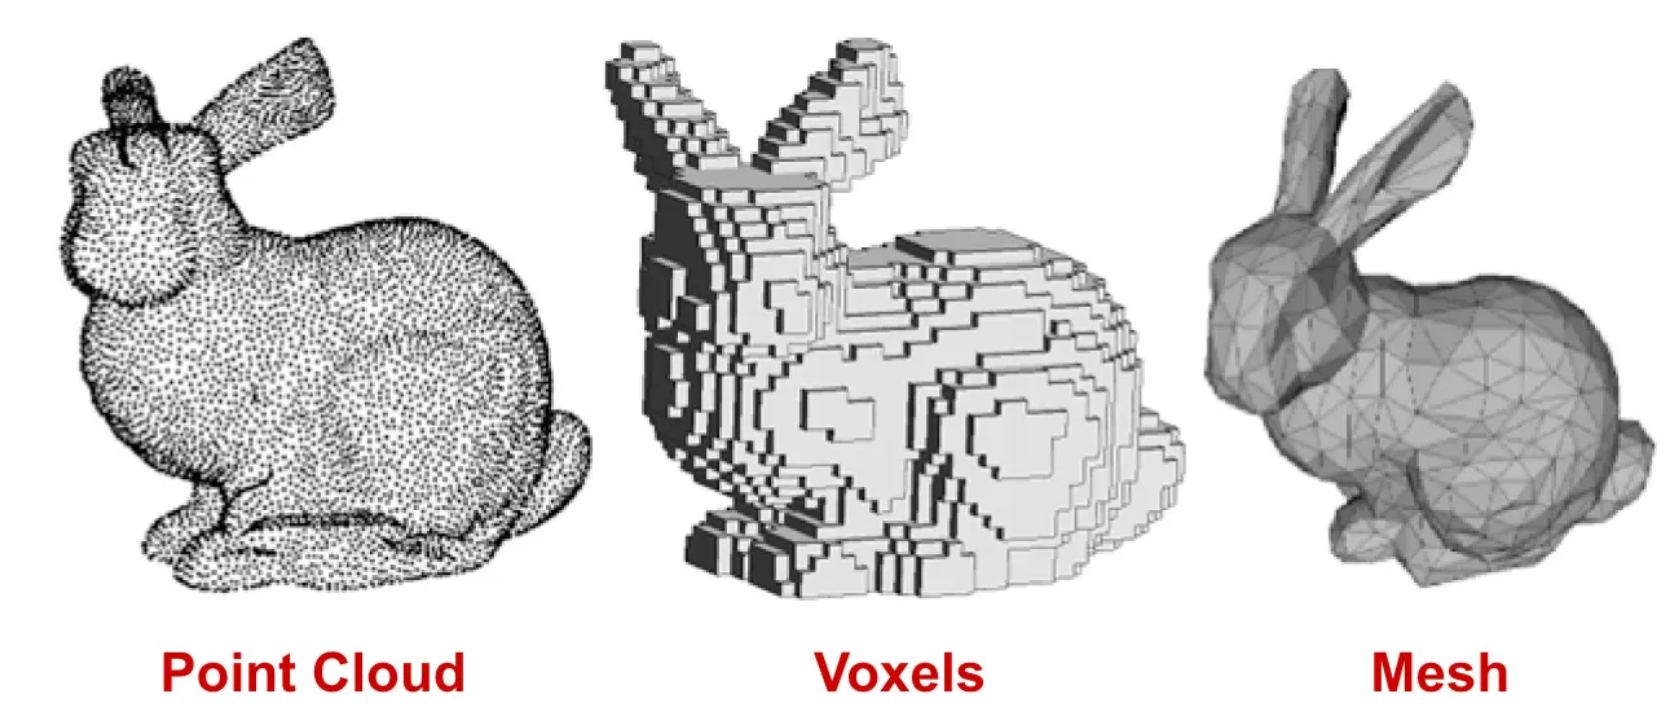

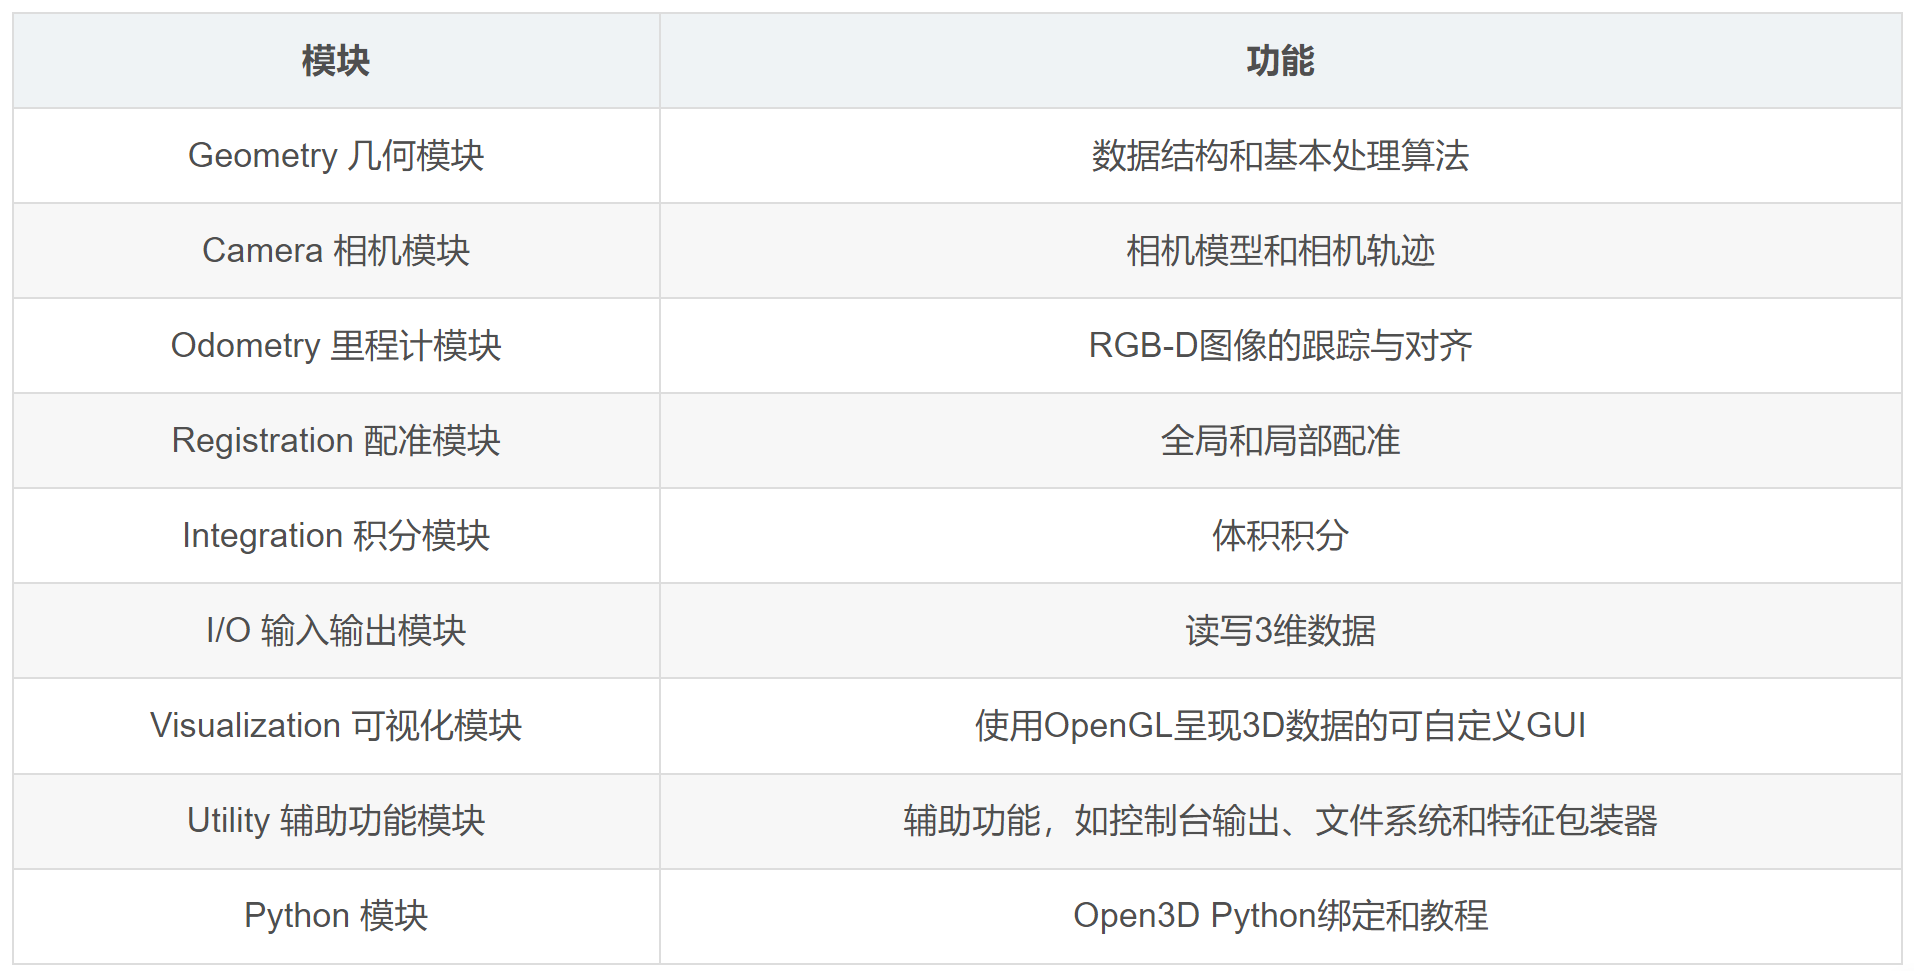

支援三種格式: Point Cloud、Mesh、RGB-D


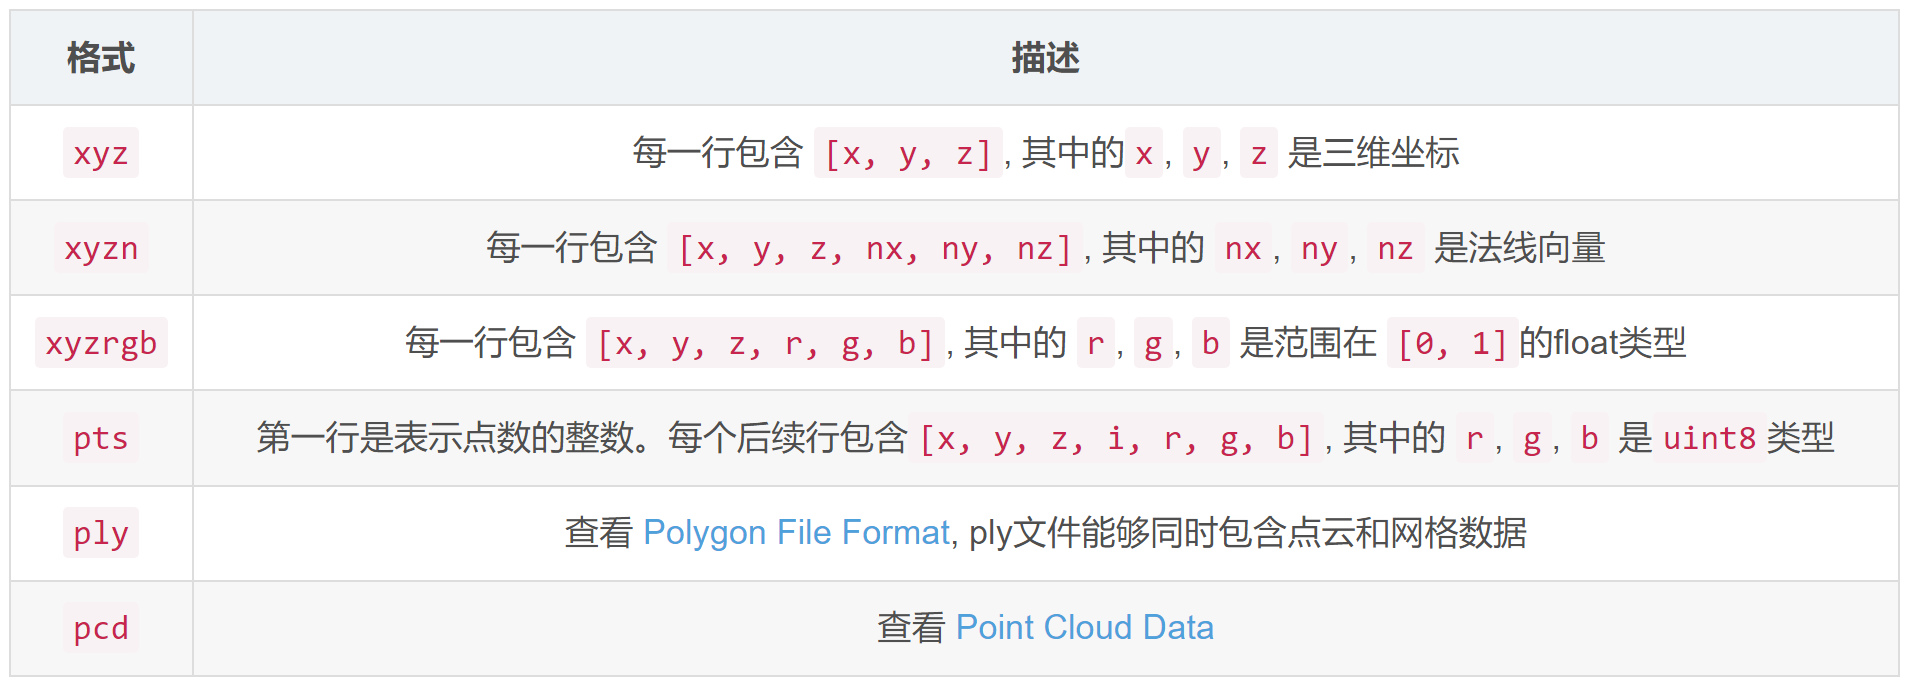

基本資料結構  

| 類型 | 類別名稱 | 功能說明|
|:------|:-----|:------|
| 點雲  | o3d.geometry.PointCloud | 儲存與操作 3D 點資料 |
| 三角網格 | o3d.geometry.TriangleMesh | 表示物體表面結構  |
| 線集合 | o3d.geometry.LineSet | 可用於邊界或骨架表示 |
| 影像 | o3d.geometry.Image | 支援灰階與彩色影像 |
| RGBD影像 | o3d.geometry.RGBDImage | 將RGB與深度影像整合 |


In [1]:
import open3d as o3d
import numpy as np
print("Load a ply point cloud, print it, and render it")
ply_point_cloud = o3d.data.PLYPointCloud()
print(ply_point_cloud.path)
pcd = o3d.io.read_point_cloud(ply_point_cloud.path)

#read_point_cloud reads a point cloud from a file. 
# It tries to decode the file based on the extension name. 
# For a list of supported file types, refer to File IO.
print(pcd)
print(np.asarray(pcd.points))

o3d.visualization.draw_geometries([pcd],zoom=0.3412,front=[0.4257, -0.2125, -0.8795],lookat=[2.6172, 2.0475, 1.532],up=[-0.0694, -0.9768, 0.2024])

#draw_geometries visualizes the point cloud. 
# Use a mouse/trackpad to see the geometry from different view points.
#It looks like a dense surface, but it is actually a point cloud rendered as surfels. 
# The GUI supports various keyboard functions. 
# For instance, the - key reduces the size of the points (surfels).


Load a ply point cloud, print it, and render it
[Open3D INFO] Downloading https://github.com/isl-org/open3d_downloads/releases/download/20220201-data/fragment.ply
[Open3D INFO] Downloaded to /Users/hjc/open3d_data/download/PLYPointCloud/fragment.ply
/Users/hjc/open3d_data/extract/PLYPointCloud/fragment.ply
PointCloud with 196133 points.
[[0.65234375 0.84686458 2.37890625]
 [0.65234375 0.83984375 2.38430572]
 [0.66737998 0.83984375 2.37890625]
 ...
 [2.00839925 2.39453125 1.88671875]
 [2.00390625 2.39488506 1.88671875]
 [2.00390625 2.39453125 1.88793314]]


o3d.visualization.draw_geometries()
| 參數名稱 | 型別 | 預設值 | 說明 |
|-----------|-------|--------|------|
| geometry_list | list | 無 | 要顯示的幾何物件清單，例如 `[pcd, mesh]`。可以包含 PointCloud、TriangleMesh、LineSet 等物件。 |
| window_name | str | "Open3D" | 視窗標題名稱。 |
| width | int | 1920 | 視窗寬度（像素）。 |
| height | int | 1080 | 視窗高度（像素）。 |
| left | int | 50 | 視窗左上角 X 座標（螢幕上偏移）。 |
| top | int | 50 | 視窗左上角 Y 座標（螢幕上偏移）。 |
| point_show_normal | bool | False | 是否顯示點雲的法向量（需先估計 normals）。 |
| mesh_show_wireframe | bool | False | 是否顯示網格線框。 |
| mesh_show_back_face | bool | False | 是否顯示背面三角形面（預設背面被剔除）。 |
| lookat | list / np.ndarray | None | 攝影機注視點位置 `[x, y, z]`。 |
| up | list / np.ndarray | None | 攝影機的上方向向量 `[x, y, z]`。 |
| front | list / np.ndarray | None | 攝影機前向向量 `[x, y, z]`。 |
| zoom | float | 0.7 | 攝影機縮放比例（值越小視角越近）。 |

open3d.visualization.draw_geometries_with_key_callbacks()
| 參數名稱 | 型別 | 預設值 | 說明 |
|-----------|-------|--------|------|
| geometry_list | list | 無 | 要顯示的幾何物件清單，例如 `[pcd, mesh]`。 |
| key_to_callback | dict | 無 | 鍵盤快捷鍵與回呼函式的對應字典，例如 `{ord("K"): func}`。 |
| window_name | str | "Open3D" | 視窗標題名稱。 |
| width | int | 1920 | 視窗寬度（像素）。 |
| height | int | 1080 | 視窗高度（像素）。 |
| left | int | 50 | 視窗左上角 X 座標。 |
| top | int | 50 | 視窗左上角 Y 座標。 |
| point_show_normal | bool | False | 是否顯示點雲法向量。 |
| mesh_show_wireframe | bool | False | 是否顯示網格線框。 |
| mesh_show_back_face | bool | False | 是否顯示背面。 |
| lookat | list / np.ndarray | None | 攝影機注視點 `[x, y, z]`。 |
| up | list / np.ndarray | None | 攝影機上方向 `[x, y, z]`。 |
| front | list / np.ndarray | None | 攝影機前方向 `[x, y, z]`。 |
| zoom | float | 0.7 | 攝影機縮放比例。 |

In [2]:
import open3d as o3d
import numpy as np

# 建立範例點雲
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(np.random.rand(1000, 3))
pcd.paint_uniform_color([0.2, 0.8, 1.0])  # 藍綠色點雲

# 定義按鍵事件函式
def zoom_in_fov(vis):
    ctr = vis.get_view_control()
    if hasattr(ctr, "change_field_of_view"):
        ctr.change_field_of_view(-5.0)   # 負值 = 視角更窄 = 近似放大
        vis.update_renderer()
    return False

def zoom_out_fov(vis):
    ctr = vis.get_view_control()
    if hasattr(ctr, "change_field_of_view"):
        ctr.change_field_of_view(+5.0)   # 視角更廣 = 近似縮小
        vis.update_renderer()
    return False


def toggle_color(vis):
    # 切換點雲顏色
    pcd.paint_uniform_color(np.random.rand(3))
    vis.update_geometry(pcd)
    print("🎨 Changed Color")
    return False

def save_screenshot(vis):
    vis.capture_screen_image("screenshot.png")
    print("📸 Screenshot saved as screenshot.png")
    return False

def downsample(vis):
    """按 D 鍵進行 voxel downsample"""
    global pcd
    # 執行 downsample
    downsampled_pcd = pcd.voxel_down_sample(voxel_size=0.02)
    pcd = downsampled_pcd
    # 更新視窗顯示
    vis.clear_geometries()
    vis.add_geometry(pcd)
    vis.poll_events()
    vis.update_renderer()
    print(f"Downsampled! Current points: {len(pcd.points)}")
    return False

# 建立快捷鍵對應字典
key_to_callback = {
    ord("Z"): zoom_in_fov,      # 按 Z 放大fov
    ord("X"): zoom_out_fov,     # 按 X 縮小fov
    ord("C"): toggle_color,     # 按 C 換顏色
    ord("S"): save_screenshot,  # 按 S 截圖
    ord("D"): downsample,       # 按 D 進行 downsample
}

# 啟動可互動視窗
o3d.visualization.draw_geometries_with_key_callbacks(
    [pcd],
    key_to_callback=key_to_callback,
    window_name="Interactive PointCloud Example",
    width=960,
    height=720
)

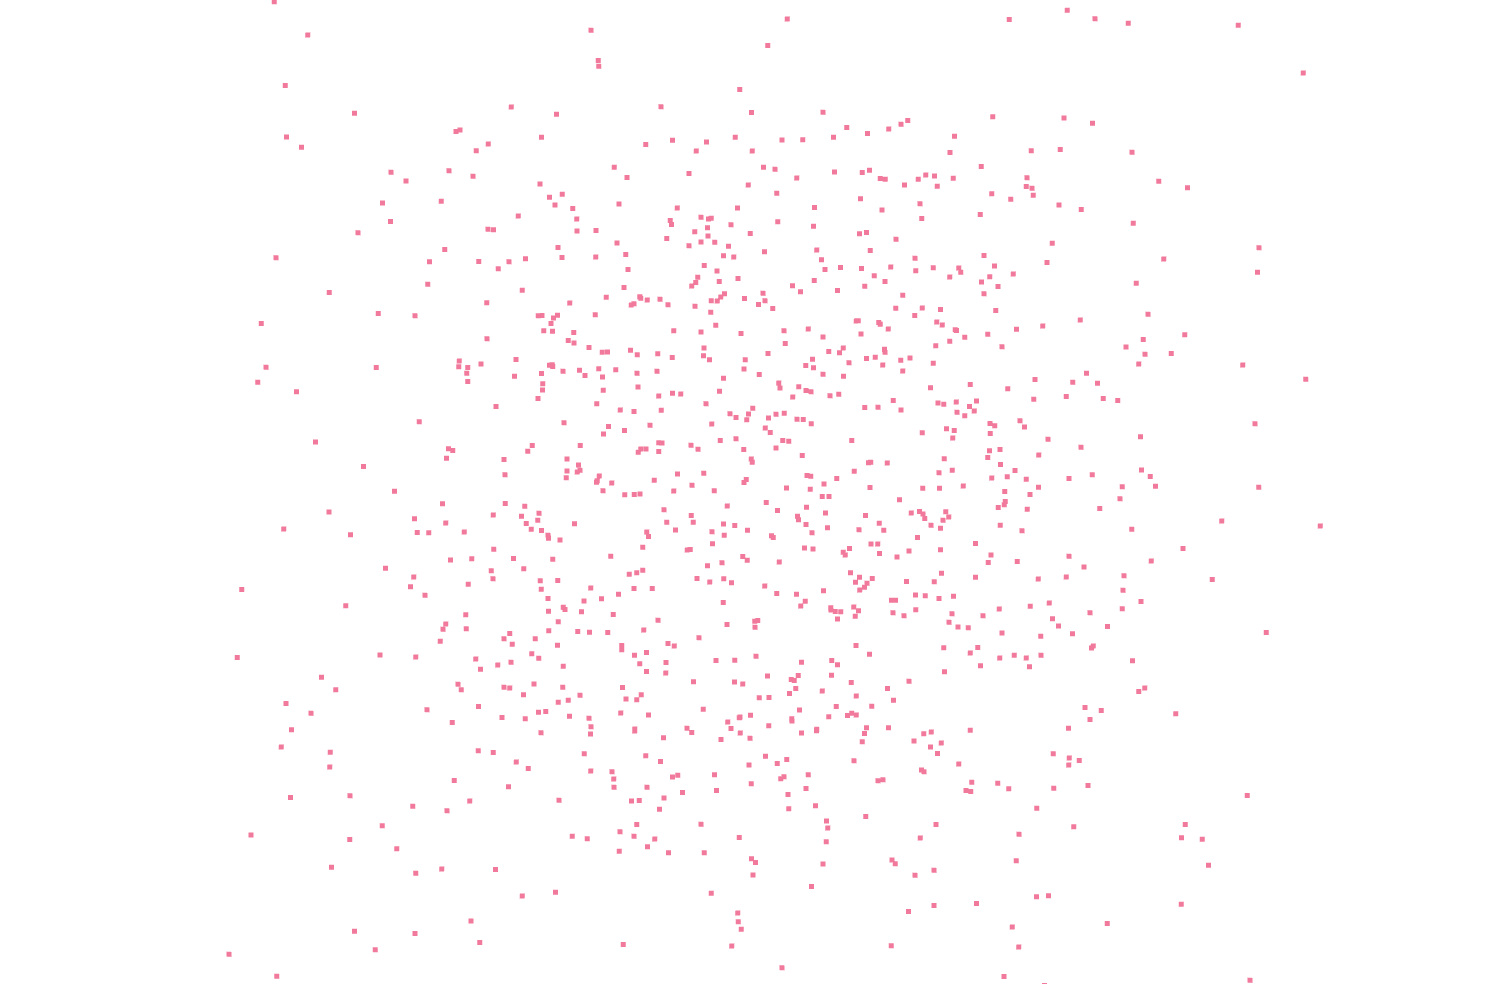

In [ ]:
import open3d as o3d
import numpy as np
print("Load a ply point cloud, print it, and render it")
ply_point_cloud = o3d.data.PLYPointCloud()
print(ply_point_cloud.path)
pcd = o3d.io.read_point_cloud(ply_point_cloud.path)

print("Downsample the point cloud with a voxel of 0.05")
downpcd = pcd.voxel_down_sample(voxel_size=0.001)
o3d.visualization.draw_geometries([downpcd],
                                  zoom=0.3412,
                                  front=[0.4257, -0.2125, -0.8795],
                                  lookat=[2.6172, 2.0475, 1.532],
                                  up=[-0.0694, -0.9768, 0.2024])
'''
Voxel downsampling
Voxel downsampling uses a regular voxel grid to create a uniformly downsampled point cloud from an input point cloud. 
It is often used as a pre-processing step for many point cloud processing tasks. 
The algorithm operates in two steps:
1. Points are bucketed into voxels.
2. Each occupied voxel generates exactly one point by averaging all points inside.
'''
def downsample_callback(vis):
    global pcd
    downpcd = pcd.voxel_down_sample(voxel_size=0.05)
    pcd = downpcd
    
    vis.clear_geometries()
    vis.add_geometry(pcd)
    vis.poll_events()
    vis.update_renderer()
    
    print(f"Downsampled! Current points: {len(pcd.points)}")
    return False

key_to_callback = {
    ord("D"): downsample_callback,  # 按 D 進行 downsample
}

Load a ply point cloud, print it, and render it
/Users/hjc/open3d_data/extract/PLYPointCloud/fragment.ply
Downsample the point cloud with a voxel of 0.05


'\nVoxel downsampling\nVoxel downsampling uses a regular voxel grid to create a uniformly downsampled point cloud from an input point cloud. \nIt is often used as a pre-processing step for many point cloud processing tasks. \nThe algorithm operates in two steps:\n1. Points are bucketed into voxels.\n2. Each occupied voxel generates exactly one point by averaging all points inside.\n'

In [ ]:
print("Recompute the normal of the downsampled point cloud")
downpcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
o3d.visualization.draw_geometries([downpcd],
                                  zoom=0.3412,
                                  front=[0.4257, -0.2125, -0.8795],
                                  lookat=[2.6172, 2.0475, 1.532],
                                  up=[-0.0694, -0.9768, 0.2024],
                                  point_show_normal=True)
'''
estimate_normals computes the normal for every point. 
The function finds adjacent points and calculates the principal axis of the adjacent points using covariance analysis.

The function takes an instance of KDTreeSearchParamHybrid class as an argument. 
The two key arguments radius = 0.1 and max_nn = 30 specifies search radius and maximum nearest neighbor. 
It has 10cm of search radius, and only considers up to 30 neighbors to save computation time.

The covariance analysis algorithm produces two opposite directions as normal candidates. 
Without knowing the global structure of the geometry, both can be correct. 
This is known as the normal orientation problem. Open3D tries to orient the normal to align with the original normal if it exists. 
Otherwise, Open3D does a random guess. Further orientation functions such as orient_normals_to_align_with_direction 
and orient_normals_towards_camera_location need to be called if the orientation is a concern.
'''
print("Print a normal vector of the 0th point")
print(downpcd.normals[0])

print("Print the normal vectors of the first 10 points")
print(np.asarray(downpcd.normals)[:10, :])



In [ ]:
print("Load a polygon volume and use it to crop the original point cloud")
demo_crop_data = o3d.data.DemoCropPointCloud()
pcd = o3d.io.read_point_cloud(demo_crop_data.point_cloud_path)
o3d.visualization.draw_geometries([pcd],
                                  zoom=0.3412,
                                  front=[0.4257, -0.2125, -0.8795],
                                  lookat=[2.6172, 2.0475, 1.532],
                                  up=[-0.0694, -0.9768, 0.2024],
                                 )
vol = o3d.visualization.read_selection_polygon_volume(demo_crop_data.cropped_json_path)
print(demo_crop_data.cropped_json_path)
chair = vol.crop_point_cloud(pcd)
o3d.visualization.draw_geometries([chair],
                                  zoom=0.7,
                                  front=[0.5439, -0.2333, -0.8060],
                                  lookat=[2.4615, 2.1331, 1.338],
                                  up=[-0.1781, -0.9708, 0.1608])

'''
read_selection_polygon_volume reads a json file that specifies polygon selection area. 
vol.crop_point_cloud(pcd) filters out points. Only the chair remains.
'''


In [ ]:
print("Paint chair")
chair.paint_uniform_color([1, 0.706, 0])
o3d.visualization.draw_geometries([chair],
                                  zoom=0.7,
                                  front=[0.5439, -0.2333, -0.8060],
                                  lookat=[2.4615, 2.1331, 1.338],
                                  up=[-0.1781, -0.9708, 0.1608])
'''
paint_uniform_color paints all the points to a uniform color. The color is in RGB space, [0, 1] range.
'''

In [ ]:
# Load data
demo_crop_data = o3d.data.DemoCropPointCloud()
pcd = o3d.io.read_point_cloud(demo_crop_data.point_cloud_path)
vol = o3d.visualization.read_selection_polygon_volume(demo_crop_data.cropped_json_path)
chair = vol.crop_point_cloud(pcd)

dists = pcd.compute_point_cloud_distance(chair)
dists = np.asarray(dists)
ind = np.where(dists > 0.01)[0]
print(np.where(dists > 0.01))
print(ind)
pcd_without_chair = pcd.select_by_index(ind)
o3d.visualization.draw_geometries([pcd_without_chair],
                                  zoom=0.3412,
                                  front=[0.4257, -0.2125, -0.8795],
                                  lookat=[2.6172, 2.0475, 1.532],
                                  up=[-0.0694, -0.9768, 0.2024])

'''
Point cloud distance
Open3D provides the method compute_point_cloud_distance to compute the distance from a source point cloud to a target point cloud. 
I.e., it computes for each point in the source point cloud the distance to the closest point in the target point cloud.

In the example below we use the function to compute the difference between two point clouds. 
Note that this method could also be used to compute the Chamfer distance between two point clouds.
'''

In [ ]:
aabb = chair.get_axis_aligned_bounding_box()
aabb.color = (1, 0, 0)
obb = chair.get_oriented_bounding_box()
obb.color = (0, 1, 0)
o3d.visualization.draw_geometries([chair, aabb, obb],
                                  zoom=0.7,
                                  front=[0.5439, -0.2333, -0.8060],
                                  lookat=[2.4615, 2.1331, 1.338],
                                  up=[-0.1781, -0.9708, 0.1608])
'''
The PointCloud geometry type has bounding volumes as all other geometry types in Open3D. 
Currently, Open3D implements an AxisAlignedBoundingBox and an OrientedBoundingBox that can also be used to crop the geometry.
'''

| 函數 | AxisAlignedBoundingBox | OrientedBoundingBox |
|------|------------------------|---------------------|
| 對齊方式 | 與全域座標軸平行 | 與點雲主方向平行 |
| 緊密程度 | 較鬆 | 較緊密 |
| 計算方式 | 取 xyz min/max | PCA 找主軸方向 |
| 計算速度 | 快 | 稍慢 |
| 適用場景 | 快速粗略包圍、碰撞偵測 | 精準形狀擬合、姿態估測 |

| 類別 | 屬性 / 方法 | 說明 |
|------|--------------|------|
| AxisAlignedBoundingBox | `.min_bound` / `.max_bound` | 對應 X/Y/Z 軸方向的最小與最大座標 |
| AxisAlignedBoundingBox | `.get_extent()` | 傳回長寬高 |
| AxisAlignedBoundingBox | `.get_center()` | 傳回中心點 |
| OrientedBoundingBox | `.center` | 盒子中心 |
| OrientedBoundingBox | `.extent` | 長寬高（沿主軸方向） |
| OrientedBoundingBox | `.R` | 3×3 旋轉矩陣（描述方向） |
| OrientedBoundingBox | `.get_oriented_bounding_box()` | 由點雲產生 OBB |

In [ ]:
bunny = o3d.data.BunnyMesh()
mesh = o3d.io.read_triangle_mesh(bunny.path)
mesh.compute_vertex_normals()

pcl = mesh.sample_points_poisson_disk(number_of_points=2000)
hull, _ = pcl.compute_convex_hull()
hull_ls = o3d.geometry.LineSet.create_from_triangle_mesh(hull)
hull_ls.paint_uniform_color((1, 0, 0))
o3d.visualization.draw_geometries([pcl, hull_ls])

'''
The convex hull of a point cloud is the smallest convex set that contains all points. 
Open3D contains the method compute_convex_hull that computes the convex hull of a point cloud. 
The implementation is based on Qhull.

In the example code below we first sample a point cloud from a mesh and compute the convex hull that is returned as a triangle mesh. 
Then, we visualize the convex hull as a red LineSet.
'''

In [ ]:
import open3d as o3d
import matplotlib.pyplot as plt
import numpy as np
ply_point_cloud = o3d.data.PLYPointCloud()
pcd = o3d.io.read_point_cloud(ply_point_cloud.path)

with o3d.utility.VerbosityContextManager(
        o3d.utility.VerbosityLevel.Debug) as cm:
    labels = np.array(
        pcd.cluster_dbscan(eps=0.02, min_points=10, print_progress=True))
print(labels)
max_label = labels.max()
print(max_label)
print(f"point cloud has {max_label + 1} clusters")
colors = plt.get_cmap("tab20")(labels / (max_label if max_label > 0 else 1))
colors[labels < 0] = 0
pcd.colors = o3d.utility.Vector3dVector(colors[:, :3])
o3d.visualization.draw_geometries([pcd],
                                  zoom=0.455,
                                  front=[-0.4999, -0.1659, -0.8499],
                                  lookat=[2.1813, 2.0619, 2.0999],
                                  up=[0.1204, -0.9852, 0.1215])

'''
DBSCAN clustering
Given a point cloud from e.g. a depth sensor we want to group local point cloud clusters together. 
For this purpose, we can use clustering algorithms. Open3D implements DBSCAN [Ester1996] that is a density based clustering algorithm. 
The algorithm is implemented in cluster_dbscan and requires two parameters: eps defines the distance to neighbors in a 
cluster and min_points defines the minimum number of points required to form a cluster. 
The function returns labels, where the label -1 indicates noise.
This algorithm precomputes all neighbors in the epsilon radius for all points. This can require a lot of memory if the chosen epsilon is too large.
'''

In [3]:
pcd_point_cloud = o3d.data.PCDPointCloud()
pcd = o3d.io.read_point_cloud(pcd_point_cloud.path)

plane_model, inliers = pcd.segment_plane(distance_threshold=0.03, #微調視點雲尺度
                                         ransac_n=3,
                                         num_iterations=3000)
[a, b, c, d] = plane_model
print(f"Plane equation: {a:.2f}x + {b:.2f}y + {c:.2f}z + {d:.2f} = 0")

inlier_cloud = pcd.select_by_index(inliers)
inlier_cloud.paint_uniform_color([1.0, 0, 0])
outlier_cloud = pcd.select_by_index(inliers, invert=True)
o3d.visualization.draw_geometries([inlier_cloud, outlier_cloud],
                                  zoom=0.8,
                                  front=[-0.4999, -0.1659, -0.8499],
                                  lookat=[2.1813, 2.0619, 2.0999],
                                  up=[0.1204, -0.9852, 0.1215])

'''
Plane segmentation
Open3D also supports segmententation of geometric primitives from point clouds using RANSAC. 
To find the plane with the largest support in the point cloud, we can use segment_plane. 
The method has three arguments: distance_threshold defines the maximum distance a point can have to an estimated plane to be considered an inlier, 
ransac_n defines the number of points that are randomly sampled to estimate a plane, and num_iterations defines how often a random plane is sampled and verified. 
The function then returns the plane as (a,b,c,d) such that for each point (x,y,z) on the plane we have ax+by+cz+d=0
. The function further returns a list of indices of the inlier points.
'''

Plane equation: -0.05x + -0.10y + 0.99z + -1.07 = 0


2025-11-06 20:55:36.858 python[17004:10381096] TSM AdjustCapsLockLEDForKeyTransitionHandling - _ISSetPhysicalKeyboardCapsLockLED Inhibit
2025-11-06 20:55:36.864 python[17004:10381096] error messaging the mach port for IMKCFRunLoopWakeUpReliable


'\nPlane segmentation\nOpen3D also supports segmententation of geometric primitives from point clouds using RANSAC. \nTo find the plane with the largest support in the point cloud, we can use segment_plane. \nThe method has three arguments: distance_threshold defines the maximum distance a point can have to an estimated plane to be considered an inlier, \nransac_n defines the number of points that are randomly sampled to estimate a plane, and num_iterations defines how often a random plane is sampled and verified. \nThe function then returns the plane as (a,b,c,d) such that for each point (x,y,z) on the plane we have ax+by+cz+d=0\n. The function further returns a list of indices of the inlier points.\n'

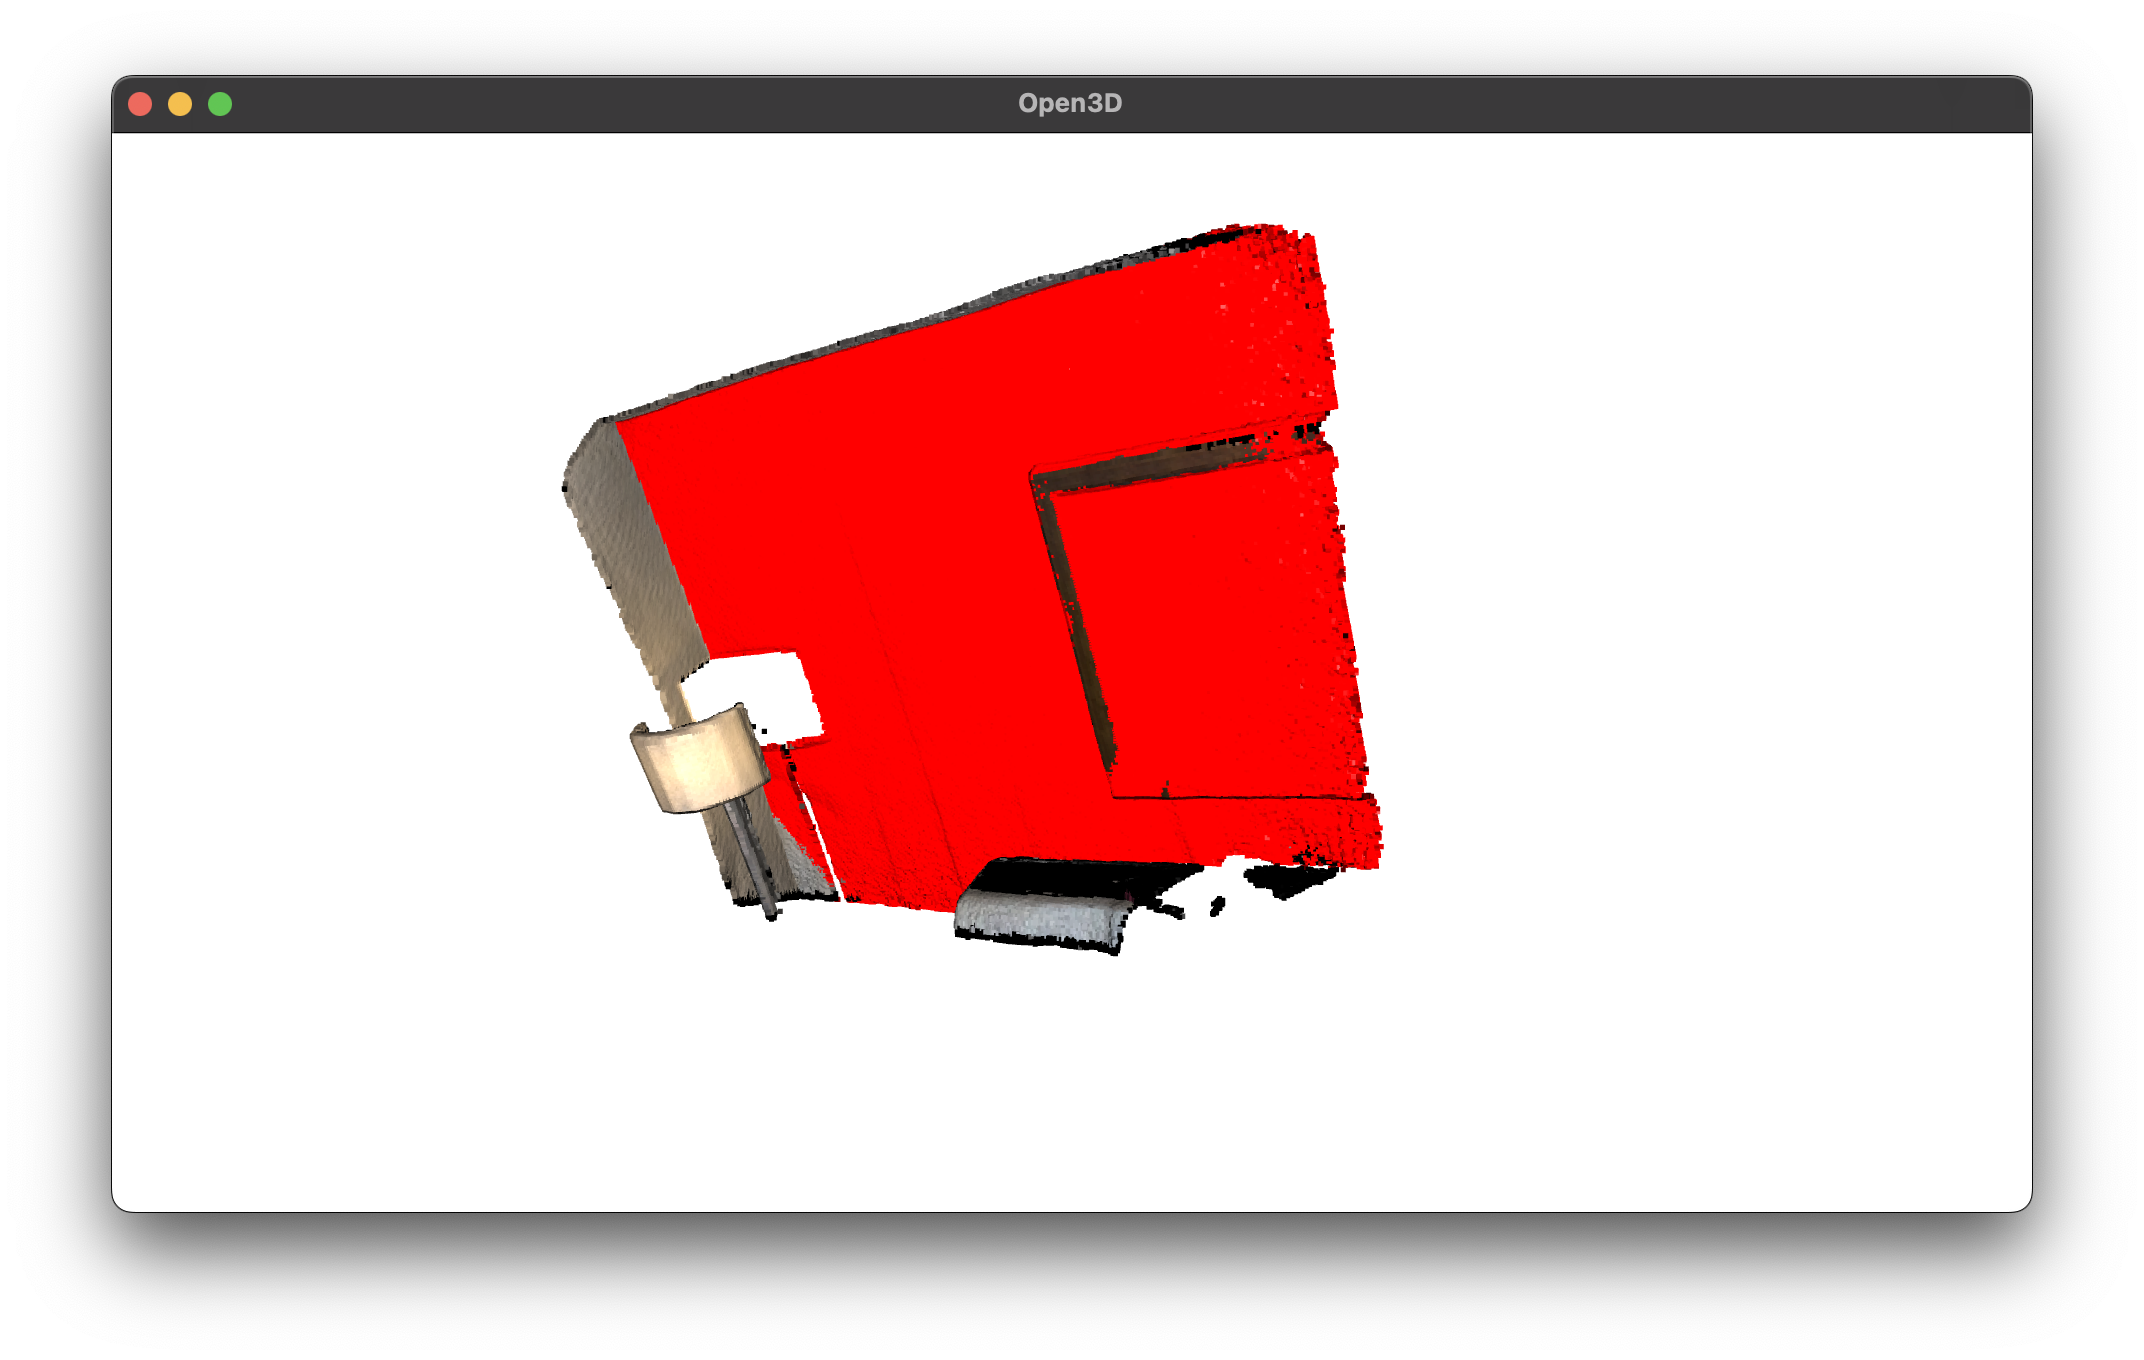

In [ ]:
dataset = o3d.data.PCDPointCloud()
pcd = o3d.io.read_point_cloud(dataset.path)
assert (pcd.has_normals())

# using all defaults
oboxes = pcd.detect_planar_patches(
    normal_variance_threshold_deg=60,
    coplanarity_deg=75,
    outlier_ratio=0.75,
    min_plane_edge_length=0,
    min_num_points=0,
    search_param=o3d.geometry.KDTreeSearchParamKNN(knn=30))

print("Detected {} patches".format(len(oboxes)))

geometries = []
for obox in oboxes:
    mesh = o3d.geometry.TriangleMesh.create_from_oriented_bounding_box(obox, scale=[1, 1, 0.0001])
    mesh.paint_uniform_color(obox.color)
    geometries.append(mesh)
    geometries.append(obox)
geometries.append(pcd)

o3d.visualization.draw_geometries(geometries,
                                  zoom=0.62,
                                  front=[0.4361, -0.2632, -0.8605],
                                  lookat=[2.4947, 1.7728, 1.5541],
                                  up=[-0.1726, -0.9630, 0.2071])

'''
Planar patch detection
In addition to finding the single plane with the largest support, Open3D includes an algorithm which uses a robust 
statistics-based approach for planar patch detection [ArujoAndOliveira2020]. 
This algorithm first subdivides the point cloud into smaller chunks (using an octree), then attempts to fit a plane to each chunk. 
If the plane passes a robust planarity test, then it is accepted. 
A plane is fitted to a subset of points by taking the median point position and the median point normal and estimating a plane ax+by+cz+d=0
. The robust planarity check consists of two main components. 
First, the distribution of angles between each point normal and the fitted plane normal is found. 
If the spread of this distribution is too high (i.e., there is too much variance amongst all of the associated point normals), 
then the plane is rejected. Second, the distribution of the distances from the fitted plane to each point is computed. 
If the spread of this distribution is too high, as measured using a coplanarity metric (see Fig. 4 of [ArujoAndOliveira2020]), 
then the plane is rejected. After an initial set of planes are found, an iterative procedure is used to grow and merge planes into a 
smaller, stable set of planes. These planes can then be bounded using the 2D convex hull of their associated point sets and planar patches are extracted.

To find a list of planar patches in a point cloud, we can use detect_planar_patches. This method can take six arguments: 
normal_variance_threshold_deg controls the amount of variance allowed amongst the point normals and takes 60∘
 as its default. Smaller values tends to result in fewer, higher quality planes. 
 coplanarity_deg controls the allowed distribution of point distances from the plane and takes 75∘
 as its default. Larger values encourage a tighter distribution of points around the fitted plane. 
 outlier_ratio sets the maximum allowable outlier ratio in a fitted planes associated set of points before being rejected and has the default value of 0.75. 
 min_plane_edge_length is used to reject false positives—a planar patch’s largest edge much be greater than this value to be considered a true planar patch. 
 If left at 0, the algorithm defaults to using a value of 1% of the point clouds largest dimension. min_num_points determines how deep the associated 
 octree becomes and how many points must be present when attempting to fit a plane. If left at 0, the algorithm defaults to 0.1% of 
 the number of points in the point cloud. search_param is an instance of geometry::KDTreeSearchParam and defaults to geometry::KDTreeSearchParamKNN. 
 The k nearest neighbors to each point are used when growing and merging planes. Larger values of k tend to produce higher quality patches 
 at the expense of computation. This function then returns a list of detected planar patches, represented as geometry::OrientedBoundingBox objects, 
 with the third column (i.e., z) of R indicating the planar patch normal vector. The extent in the z
 direction is non-zero so that the OrientedBoundingBox contains the points that contribute to the plane detection. 
 The planar patches can be visualized using the geometry::TriangleMesh::CreateFromOrientedBoundingBox factory function, using the scale parameter 
 to “flatten” the bounding box along the normal, i.e., CreateFromOrientedBoundingBox(obox, scale=[1, 1, 0.0001]).
'''

In [ ]:
print("Convert mesh to a point cloud and estimate dimensions")
armadillo = o3d.data.ArmadilloMesh()
mesh = o3d.io.read_triangle_mesh(armadillo.path)
mesh.compute_vertex_normals()

pcd = mesh.sample_points_poisson_disk(5000)
diameter = np.linalg.norm(
    np.asarray(pcd.get_max_bound()) - np.asarray(pcd.get_min_bound()))
o3d.visualization.draw_geometries([pcd])

'''
Hidden point removal
Imagine you want to render a point cloud from a given view point, but points from the background leak into the foreground because they are not occluded by other points. 
For this purpose we can apply a hidden point removal algorithm. 
In Open3D the method by [Katz2007] is implemented that approximates the visibility of a point cloud from a given view without surface reconstruction or normal estimation.
'''


In [ ]:
print("Define parameters used for hidden_point_removal")
camera = [0, 0, diameter]
radius = diameter * 100

print("Get all points that are visible from given view point")
_, pt_map = pcd.hidden_point_removal(camera, radius)

print("Visualize result")
pcd = pcd.select_by_index(pt_map)
o3d.visualization.draw_geometries([pcd])

In [40]:
import open3d as o3d
import numpy as np

pcd = o3d.io.read_point_cloud('bunnyData.pts')
alpha  = 0.01
mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(pcd, alpha)
mesh.compute_vertex_normals()
o3d.visualization.draw_geometries([mesh],mesh_show_back_face=True)

In [ ]:
print("Testing mesh in Open3D...")
#armadillo_mesh = o3d.data.ArmadilloMesh()
#mesh = o3d.io.read_triangle_mesh(armadillo_mesh.path)

knot_mesh = o3d.data.KnotMesh()
mesh = o3d.io.read_triangle_mesh(knot_mesh.path)
print(mesh)
print('Vertices:')
print(np.asarray(mesh.vertices))
print('Triangles:')
print(np.asarray(mesh.triangles))

'''
Open3D has a data structure for 3D triangle meshes called TriangleMesh. 
The code below shows how to read a triangle mesh from a ply file and print its vertices and triangles.
The TriangleMesh class has a few data fields such as vertices and triangles. 
Open3D provides direct memory access to these fields via numpy.
'''

In [ ]:
print("Try to render a mesh with normals (exist: " +
      str(mesh.has_vertex_normals()) + ") and colors (exist: " +
      str(mesh.has_vertex_colors()) + ")")
o3d.visualization.draw_geometries([mesh])
print("A mesh with no normals and no colors does not look good.")

'''
You can rotate and move the mesh but it is painted with uniform gray color and does not look 3d. 
The reason is that the current mesh does not have normals for vertices or faces. 
So uniform color shading is used instead of a more sophisticated Phong shading.
'''

In [ ]:
print("Computing normal and rendering it.")
mesh.compute_vertex_normals()
print(np.asarray(mesh.triangle_normals))
o3d.visualization.draw_geometries([mesh])
'''
It uses compute_vertex_normals and paint_uniform_color which are member functions of mesh.
'''

In [ ]:
import copy
print("We make a partial mesh of only the first half triangles.")
mesh1 = copy.deepcopy(mesh)
mesh1.triangles = o3d.utility.Vector3iVector(
    np.asarray(mesh1.triangles)[:len(mesh1.triangles) // 2, :])
mesh1.triangle_normals = o3d.utility.Vector3dVector(
    np.asarray(mesh1.triangle_normals)[:len(mesh1.triangle_normals) // 2, :])
print(mesh1.triangles)
o3d.visualization.draw_geometries([mesh1])

'''
We remove half of the surface by directly operating on the triangle and triangle_normals data fields of the mesh. This is done via numpy.
'''

In [ ]:
print("Painting the mesh")
mesh1.paint_uniform_color([1, 0.706, 0])
o3d.visualization.draw_geometries([mesh1])
'''
paint_uniform_color paints the mesh with a uniform color. The color is in RGB space, [0, 1] range.
'''

In [51]:
pcd = o3d.io.read_point_cloud('milk.pcd')
o3d.visualization.draw_geometries([pcd])